# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works:-Image classification is the task of teaching a computer to recognize and assign a label to an image. The model learns patterns such as shapes, colors, edges, and textures from training images and then predicts the correct category for new images.

Example: Given an image, the model predicts whether it is an airplane, car, cat, dog, or another class in the CIFAR-10 dataset.

- Why **CNN performs better than ANN**:-An Artificial Neural Network (ANN) treats every pixel as an independent input and does not consider the spatial relationships between neighboring pixels. This leads to a large number of parameters and less effective feature learning.

A Convolutional Neural Network (CNN) uses convolution layers to automatically detect important features such as edges, corners, textures, and object parts. CNNs:

Require fewer parameters
Preserve spatial information
Learn hierarchical features automatically
Achieve higher accuracy on image data

Result: CNNs are specifically designed for image-related tasks and usually outperform ANNs in image classification.

- How architecture impacts performance:-The architecture of a neural network determines how information flows through the model and how features are learned.

Important architectural components include:

Number of layers: Deeper networks can learn more complex patterns.
Number of neurons/filters: More neurons increase learning capacity.
Convolution layers: Extract image features.
Pooling layers: Reduce image size and computation.
Dropout layers: Prevent overfitting.

A well-designed architecture can significantly improve accuracy, while a poor architecture may lead to underfitting or overfitting.

- How training strategies improve results:-Training strategies help the model learn more effectively and generalize better to unseen data.

Common strategies include:

Data Augmentation: Creates modified versions of images (rotation, flipping, zooming) to increase dataset diversity.
Batch Normalization: Stabilizes training and speeds up convergence.
Dropout: Randomly disables neurons during training to reduce overfitting.
Learning Rate Scheduling: Adjusts the learning rate during training for better optimization.
Early Stopping: Stops training when validation performance stops improving.

These techniques often improve model accuracy and robustness.

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**:-By reading the explanations and running the provided code, students will learn the complete Deep Learning workflow:

Load and preprocess image data.
Build an ANN model and evaluate its performance.
Build a CNN model and compare results.
Apply training strategies to improve performance.
Analyze accuracy, loss curves, and model behavior.

The goal is not only to achieve high accuracy but also to understand why different architectures and training techniques affect model performance.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**

Ans:-An ANN is a basic neural network where CIFAR-10 images are flattened into a 1D vector before training. It learns patterns using fully connected layers but cannot effectively capture spatial relationships between pixels.

Key Points:

Images are converted into a vector of 3072 values (32×32×3).
Uses dense (fully connected) layers.
High number of parameters.
Lower accuracy on image data.
More prone to overfitting.
2. **Convolutional Neural Network (CNN)**

Ans:-A CNN is specifically designed for image processing. It uses convolutional layers to automatically learn features such as edges, textures, and shapes while preserving spatial information.

Key Points:

Extracts image features automatically.
Uses convolution and pooling layers.
Requires fewer parameters than ANN.
Higher accuracy and better performance.
Better generalization on unseen images.

Then compare:
- Accuracy:-Accuracy is the percentage of correctly classified images out of the total number of images. It is one of the most common metrics used to evaluate the performance of a classification model.
- Loss curves:-Loss curves are graphs that show how the training loss and validation loss change over epochs during model training. They help monitor learning progress and detect issues such as overfitting or underfitting.
- Generalization:-Generalization is the ability of a model to perform well on new, unseen data rather than only on the data it was trained on. A well-generalized model makes accurate predictions on real-world data.
- Training strategies (dropout, batch norm, augmentation):-
Dropout

Dropout is a regularization technique that randomly deactivates a fraction of neurons during training to prevent the model from relying too heavily on specific neurons and reduce overfitting.

Batch Normalization

Batch Normalization is a technique that normalizes the outputs of a layer during training, making learning faster, more stable, and improving overall model performance.

Data Augmentation

Data Augmentation is the process of creating additional training images by applying transformations such as rotation, flipping, zooming, or shifting, which helps improve model robustness and reduce overfitting.

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

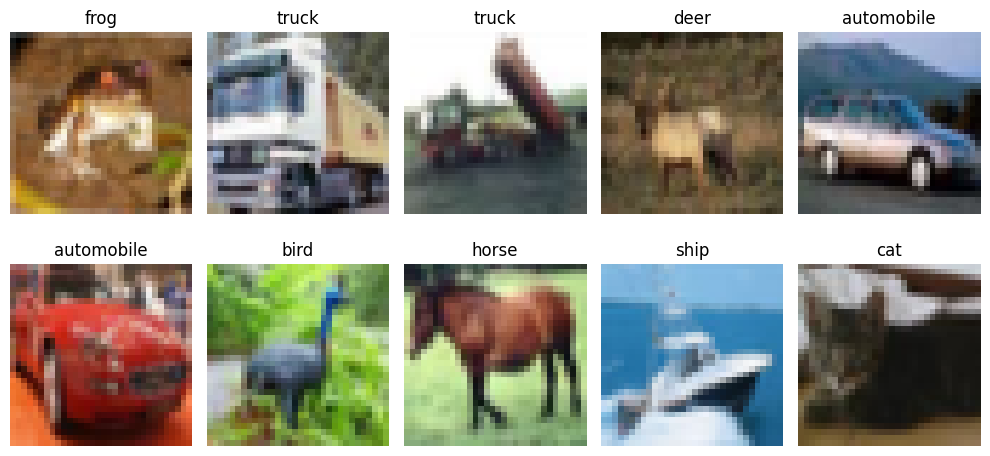

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.2598 - loss: 2.0156 - val_accuracy: 0.3210 - val_loss: 1.9123
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3074 - loss: 1.8819 - val_accuracy: 0.3520 - val_loss: 1.8044
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.3366 - loss: 1.8199 - val_accuracy: 0.3744 - val_loss: 1.7638
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.3455 - loss: 1.7974 - val_accuracy: 0.3910 - val_loss: 1.7118
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.3591 - loss: 1.7580 - val_accuracy: 0.3982 - val_loss: 1.7048
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3589 - loss: 1.7628 - val_accuracy: 0.3834 - val_loss: 1.7260
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3658 - loss: 1.7369 - val_accuracy: 0.3998 - val_loss: 1.6832
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.3714 - loss: 1.7281 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4276 - loss: 1.6337
ANN Test Accuracy: 0.4275999963283539


###Increase ANN layers and observe performance

In [ ]:
ann_model_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_deep = ann_model_deep.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

ann_test_loss_deep, ann_test_acc_deep = ann_model_deep.evaluate(
    x_test_flat,
    y_test
)

print("Deep ANN Test Accuracy:", ann_test_acc_deep)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.2577 - loss: 2.0099 - val_accuracy: 0.3206 - val_loss: 1.8606
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.3032 - loss: 1.8872 - val_accuracy: 0.3468 - val_loss: 1.8107
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 56ms/step - accuracy: 0.3258 - loss: 1.8328 - val_accuracy: 0.3746 - val_loss: 1.7610
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.3411 - loss: 1.8023 - val_accuracy: 0.3860 - val_loss: 1.7392
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.3536 - loss: 1.7713 - val_accuracy: 0.3904 - val_loss: 1.7170
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.3605 - loss: 1.7596 - val_accuracy: 0.3964 - val_loss: 1.6996
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.3643 - loss: 1.7421 - val_accuracy: 0.3882 - val_loss: 1.7193
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.3742 - loss: 1.7251 - 

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:

Ans:-Images are made up of pixels arranged in a specific order. Nearby pixels are usually related and together form edges, shapes, and objects. CNNs preserve these spatial relationships, unlike ANNs that flatten images into a 1D vector and lose positional information.
- Convolution layers:-Convolution layers use small filters (kernels) that slide across the image. These filters detect important patterns such as edges, corners, and textures while maintaining the position of these features in the image.

Example: A filter can detect the edge of a car or the outline of a cat's ear.
- Pooling:-Pooling layers reduce the size of the feature maps by keeping only the most important information. This decreases computation and helps the model focus on significant features while preserving their general location.

Example: Max Pooling keeps the strongest feature value from a small region.
- Feature extraction:-CNNs automatically learn useful features directly from images. Early layers learn simple features like edges and colors, while deeper layers learn more complex patterns such as wheels, eyes, or animal faces.

Example:

Layer 1 → Edges
Layer 2 → Shapes
Layer 3 → Object Parts
Layer 4 → Complete Objects
- Hierarchical learning:-CNNs learn features in a hierarchical manner, starting with simple patterns and gradually combining them into complex representations.

For example, to recognize a dog:

First layer detects edges.
Next layers detect ears, eyes, and fur patterns.
Deeper layers combine these features to identify the entire dog.

This is why CNN performs much better for image tasks.

Ans:-Because CNNs preserve spatial information, automatically extract features, and learn patterns hierarchically, they can understand image content much more effectively than ANNs. This results in higher accuracy, better feature learning, and stronger generalization on image classification tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.4600 - loss: 1.5088 - val_accuracy: 0.5326 - val_loss: 1.3114
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 106ms/step - accuracy: 0.5979 - loss: 1.1358 - val_accuracy: 0.5690 - val_loss: 1.1837
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.6626 - loss: 0.9610 - val_accuracy: 0.5290 - val_loss: 1.5924
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.7056 - loss: 0.8450 - val_accuracy: 0.6408 - val_loss: 1.0816
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.7373 - loss: 0.7524 - val_accuracy: 0.7044 - val_loss: 0.8745
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.7610 - loss: 0.6827 - val_accuracy: 0.7282 - val_loss: 0.7961
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 106ms/step - accuracy: 0.7909 - loss: 0.6035 - val_accuracy: 0.6068 - val_loss: 1.3288
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 105ms/step - accuracy: 0.8086 - loss: 0

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6739 - loss: 1.1956
CNN Test Accuracy: 0.6739000082015991


Change CNN filters from 32→64→128

Increase epochs to 20




In [ ]:
cnn_model_improved = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

cnn_model_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_history_improved = cnn_model_improved.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 288ms/step - accuracy: 0.4642 - loss: 1.7040 - val_accuracy: 0.5046 - val_loss: 1.3808
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 290ms/step - accuracy: 0.6246 - loss: 1.0807 - val_accuracy: 0.5950 - val_loss: 1.1445
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 286ms/step - accuracy: 0.6887 - loss: 0.8979 - val_accuracy: 0.6554 - val_loss: 0.9945
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 288ms/step - accuracy: 0.7316 - loss: 0.7668 - val_accuracy: 0.6116 - val_loss: 1.1730
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 287ms/step - accuracy: 0.7677 - loss: 0.6618 - val_accuracy: 0.7116 - val_loss: 0.8287
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 287ms/step - accuracy: 0.8006 - loss: 0.5755 - val_accuracy: 0.6502 - val_loss: 1.2240
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.8242 - loss: 0.5065 - val_accuracy: 0.6702 - val_loss: 1.1349
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.8410 -

In [30]:
cnn_test_loss_improved, cnn_test_acc_improved = cnn_model_improved.evaluate(
    x_test_norm,
    y_test
)

print("Improved CNN Test Accuracy:", cnn_test_acc_improved)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7384 - loss: 1.2917
Improved CNN Test Accuracy: 0.7383999824523926


Add Early Stopping

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history_improved = cnn_model_improved.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 289ms/step - accuracy: 0.9517 - loss: 0.1456 - val_accuracy: 0.7672 - val_loss: 1.1743
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.9548 - loss: 0.1352 - val_accuracy: 0.7694 - val_loss: 1.2297
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.9552 - loss: 0.1331 - val_accuracy: 0.7430 - val_loss: 1.2911
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 207s 295ms/step - accuracy: 0.9569 - loss: 0.1268 - val_accuracy: 0.7602 - val_loss: 1.1558
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 288ms/step - accuracy: 0.9591 - loss: 0.1231 - val_accuracy: 0.7350 - val_loss: 1.4655
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 287ms/step - accuracy: 0.9560 - loss: 0.1343 - val_accuracy: 0.7620 - val_loss: 1.6276
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.9589 - loss: 0.1236 - val_accuracy: 0.7776 - val_loss: 1.1903


Add New Data Augmentation Training




In [25]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 124ms/step - accuracy: 0.4110 - loss: 1.7238 - val_accuracy: 0.4888 - val_loss: 1.4802
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.5211 - loss: 1.3566 - val_accuracy: 0.5784 - val_loss: 1.1847
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.5666 - loss: 1.2282 - val_accuracy: 0.5846 - val_loss: 1.1522
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.5973 - loss: 1.1558 - val_accuracy: 0.5788 - val_loss: 1.2299
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 120ms/step - accuracy: 0.6170 - loss: 1.0968 - val_accuracy: 0.5998 - val_loss: 1.2527
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 121ms/step - accuracy: 0.6360 - loss: 1.0437 - val_accuracy: 0.6704 - val_loss: 0.9439
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 122ms/step - accuracy: 0.6495 - loss: 1.0123 - val_accuracy: 0.6780 - val_loss: 0.9210
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6587 - los

## 📈 Compare Learning Curves

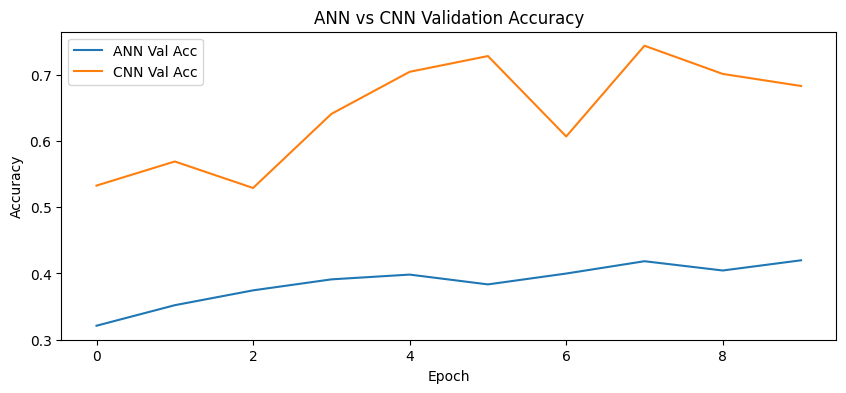

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

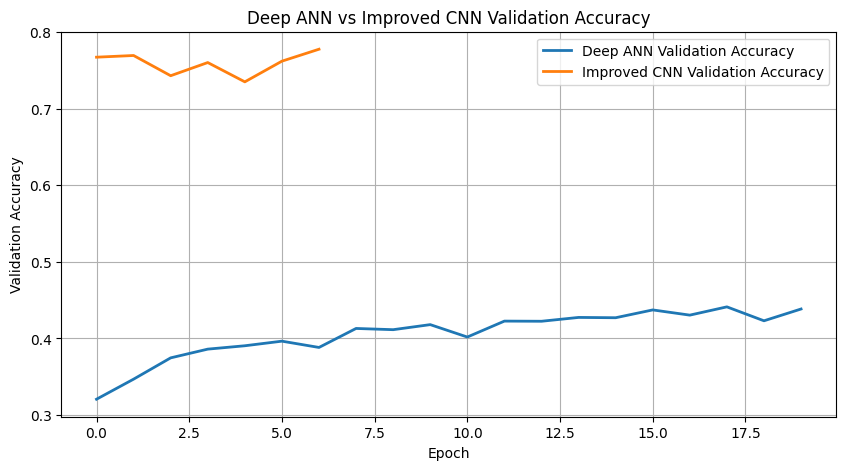

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    ann_history_deep.history['val_accuracy'],
    label='Deep ANN Validation Accuracy',
    linewidth=2
)

plt.plot(
    cnn_history_improved.history['val_accuracy'],
    label='Improved CNN Validation Accuracy',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Deep ANN vs Improved CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - accuracy: 0.3780 - loss: 1.7103 - val_accuracy: 0.4928 - val_loss: 1.3884
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 84s 47ms/step - accuracy: 0.4684 - loss: 1.4770 - val_accuracy: 0.5350 - val_loss: 1.2988
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.5038 - loss: 1.3856 - val_accuracy: 0.5586 - val_loss: 1.2210
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.5264 - loss: 1.3327 - val_accuracy: 0.6138 - val_loss: 1.0950
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 44ms/step - accuracy: 0.5438 - loss: 1.2936 - val_accuracy: 0.6120 - val_loss: 1.1025
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.5527 - loss: 1.2606 - val_accuracy: 0.6096 - val_loss: 1.1056
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.5658 - loss: 1.2321 - val_accuracy: 0.6278 - val_loss: 1.0667
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.5726 -

Add New data augmentation training

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4276
1,CNN,0.6739


In [31]:
comparison = pd.DataFrame({
    "Model": ["Deep ANN", "Improved CNN"],
    "Test Accuracy": [ann_test_acc_deep, cnn_test_acc_improved]
})

comparison

,Model,Test Accuracy
0,Deep ANN,0.4438
1,Improved CNN,0.7384


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure:-This project demonstrates the effectiveness of deep learning techniques for image classification using the CIFAR-10 dataset. Through a comparative analysis of Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs), it was observed that while ANNs can perform image classification, they are limited by their inability to preserve and learn spatial relationships within images.

- **CNN extracts spatial features**, so it performs significantly better:-In contrast, CNNs are specifically designed to process image data and effectively extract hierarchical spatial features such as edges, textures, shapes, and object patterns. As a result, CNNs achieved significantly better classification performance and generalization compared to traditional ANN architectures.

- **Training strategies** like dropout, batch norm, and augmentation improve results:-Furthermore, the incorporation of advanced training techniques, including Dropout, Batch Normalization, Data Augmentation, and Early Stopping, contributed to improved model stability, reduced overfitting, and enhanced predictive performance. These optimization strategies enabled the model to learn more robust feature representations and perform more effectively on unseen data.

- This project builds strong fundamentals for **computer vision interviews and deep learning projects**:-Overall, this project provides practical experience in image preprocessing, neural network design, model evaluation, and performance optimization. It establishes a strong foundation in computer vision and deep learning concepts, making it valuable preparation for technical interviews, academic research, and real-world machine learning applications.